In [16]:
"""
F1 RACE ANALYSIS - GP SÃO PAULO 2023
Part 2: Telemetry Analysis & Micro-Sector Comparison
"""

import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns

# Configuração de cores por piloto (padrão F1)
fastf1.plotting.setup_mpl()

In [ ]:

# 1. CARREGAMENTO DE DADOS E SELEÇÃO DE VOLTAS


print("🏎️  Carregando dados de telemetria...")

fastf1.Cache.enable_cache('/workspaces/f1-race-analysis/data/raw')
session = fastf1.get_session(2023, 'São Paulo', 'R')
session.load()

# Vamos comparar as voltas mais rápidas de dois pilotos
# Escolha P1 e P2 da corrida
results = session.results
driver_1 = results.iloc[0]['Abbreviation']
driver_2 = results.iloc[1]['Abbreviation']

print(f"\n🔍 Comparando: {driver_1} vs {driver_2}")

# Obter volta mais rápida de cada um
fastest_1 = session.laps.pick_driver(driver_1).pick_fastest()
fastest_2 = session.laps.pick_driver(driver_2).pick_fastest()

print(f"\n{driver_1} volta mais rápida: {fastest_1['LapTime']}")
print(f"{driver_2} volta mais rápida: {fastest_2['LapTime']}")

# Delta
delta = (fastest_2['LapTime'] - fastest_1['LapTime']).total_seconds()
print(f"Delta: {abs(delta):.3f}s ({driver_1 if delta > 0 else driver_2} mais rápido)")

core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


🏎️  Carregando dados de telemetria...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '14', '11', '18', '55', '10', '44', '22', '31', '2', '27', '3', '81', '63', '77', '24', '20', '23', '16']



🔍 Comparando: VER vs NOR

VER volta mais rápida: 0 days 00:01:13.422000
NOR volta mais rápida: 0 days 00:01:12.486000
Delta: 0.936s (NOR mais rápido)


/workspaces/f1-race-analysis/f1-env/lib/python3.12/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/workspaces/f1-race-analysis/f1-env/lib/python3.12/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [18]:

# 2. EXTRAIR TELEMETRIA


print("\n📡 Extraindo telemetria detalhada...")

# Telemetria contém: Speed, Throttle, Brake, Gear, RPM, DRS, etc.
tel_1 = fastest_1.get_telemetry()
tel_2 = fastest_2.get_telemetry()

print(f"✅ {driver_1}: {len(tel_1)} pontos de telemetria")
print(f"✅ {driver_2}: {len(tel_2)} pontos de telemetria")

# Adicionar coluna de distância normalizada (para comparar lado a lado)
tel_1['Distance_norm'] = tel_1['Distance'] / tel_1['Distance'].max()
tel_2['Distance_norm'] = tel_2['Distance'] / tel_2['Distance'].max()


📡 Extraindo telemetria detalhada...
✅ VER: 560 pontos de telemetria
✅ NOR: 545 pontos de telemetria


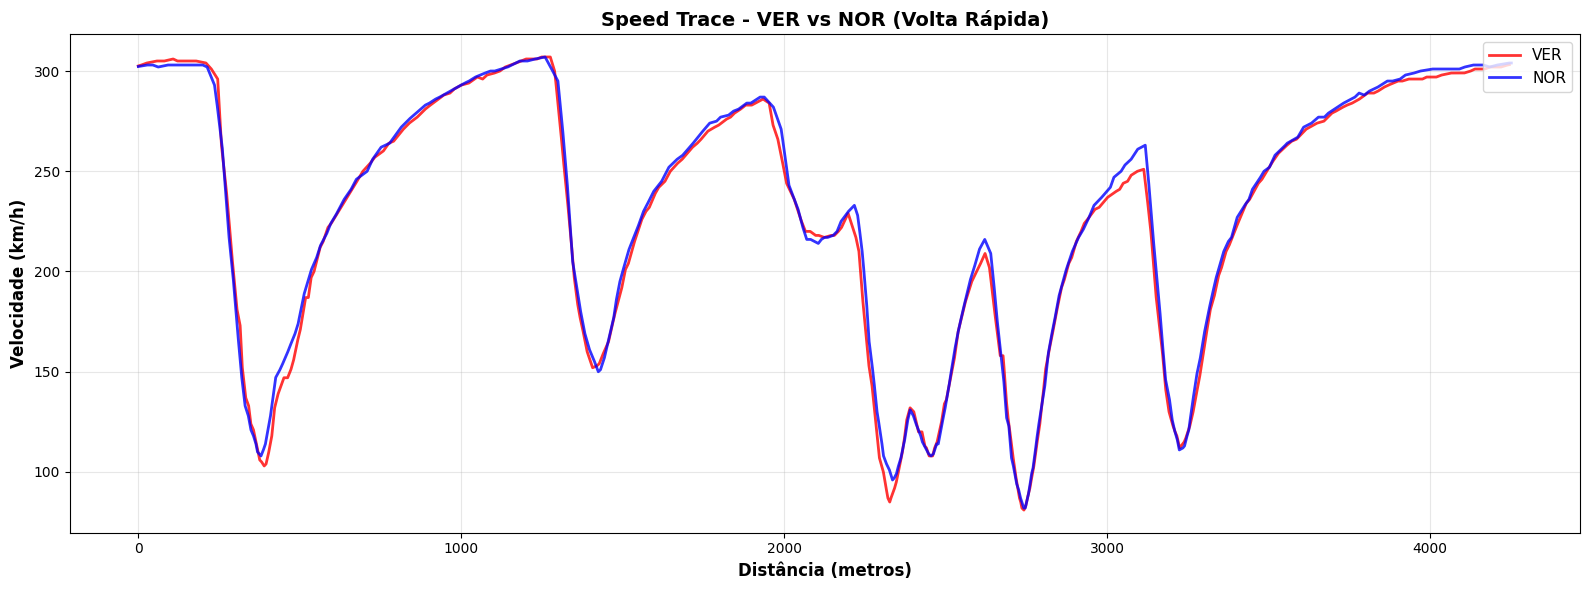

✅ Gráfico salvo: figures/04_speed_trace_comparison.png


In [19]:

# 3. VISUALIZAÇÃO: SPEED TRACE


fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(tel_1['Distance'], tel_1['Speed'], 
        label=driver_1, color='red', linewidth=2, alpha=0.8)
ax.plot(tel_2['Distance'], tel_2['Speed'], 
        label=driver_2, color='blue', linewidth=2, alpha=0.8)

ax.set_xlabel('Distância (metros)', fontsize=12, fontweight='bold')
ax.set_ylabel('Velocidade (km/h)', fontsize=12, fontweight='bold')
ax.set_title(f'Speed Trace - {driver_1} vs {driver_2} (Volta Rápida)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/04_speed_trace_comparison.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/04_speed_trace_comparison.png")

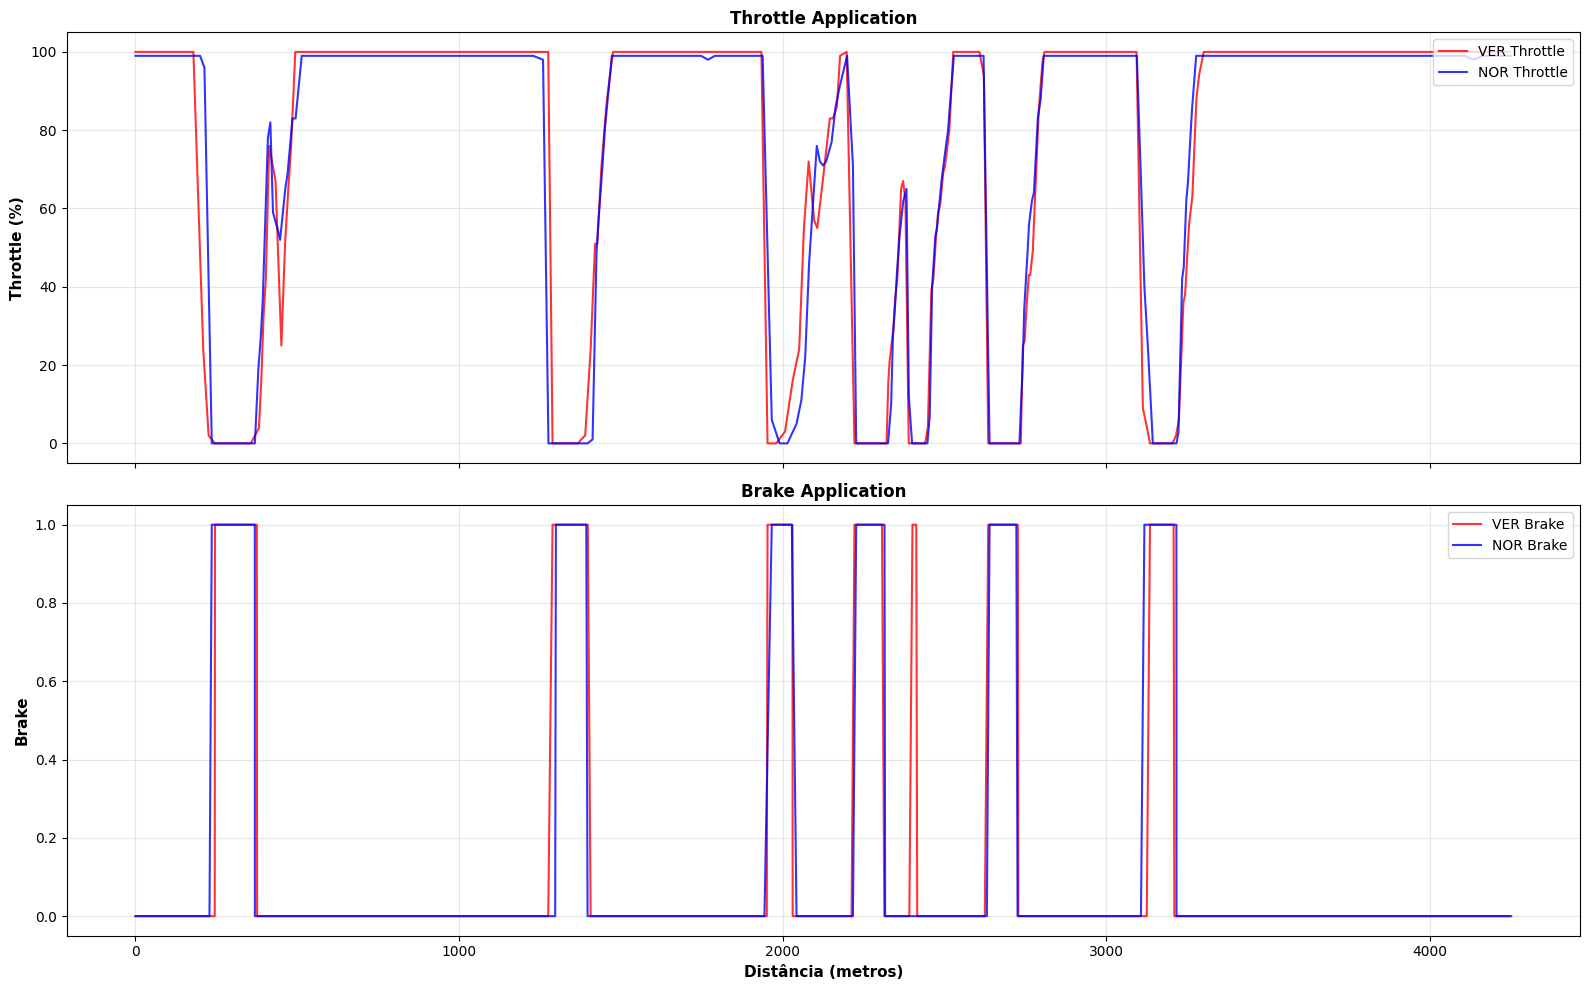

✅ Gráfico salvo: figures/05_throttle_brake_comparison.png


In [20]:

# 4. VISUALIZAÇÃO: THROTTLE & BRAKE


fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Throttle
axes[0].plot(tel_1['Distance'], tel_1['Throttle'], 
             label=f'{driver_1} Throttle', color='red', linewidth=1.5, alpha=0.8)
axes[0].plot(tel_2['Distance'], tel_2['Throttle'], 
             label=f'{driver_2} Throttle', color='blue', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Throttle (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Throttle Application', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-5, 105)

# Brake
axes[1].plot(tel_1['Distance'], tel_1['Brake'], 
             label=f'{driver_1} Brake', color='red', linewidth=1.5, alpha=0.8)
axes[1].plot(tel_2['Distance'], tel_2['Brake'], 
             label=f'{driver_2} Brake', color='blue', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Distância (metros)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Brake', fontsize=11, fontweight='bold')
axes[1].set_title('Brake Application', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/05_throttle_brake_comparison.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/05_throttle_brake_comparison.png")


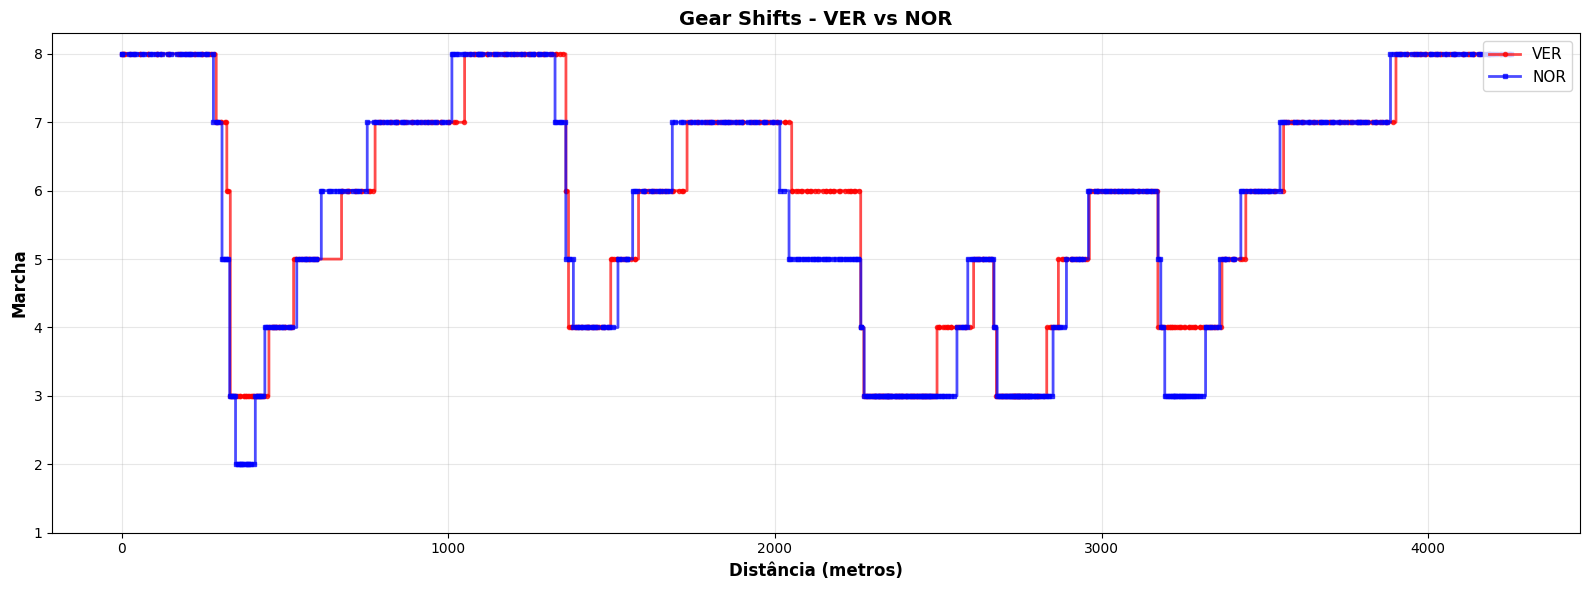

✅ Gráfico salvo: figures/06_gear_shifts_comparison.png


In [21]:

# 5. VISUALIZAÇÃO: GEAR SHIFTS


fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(tel_1['Distance'], tel_1['nGear'], 
        label=driver_1, color='red', linewidth=2, marker='o', 
        markersize=3, alpha=0.7, drawstyle='steps-post')
ax.plot(tel_2['Distance'], tel_2['nGear'], 
        label=driver_2, color='blue', linewidth=2, marker='s', 
        markersize=3, alpha=0.7, drawstyle='steps-post')

ax.set_xlabel('Distância (metros)', fontsize=12, fontweight='bold')
ax.set_ylabel('Marcha', fontsize=12, fontweight='bold')
ax.set_title(f'Gear Shifts - {driver_1} vs {driver_2}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yticks(range(1, 9))

plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/06_gear_shifts_comparison.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/06_gear_shifts_comparison.png")

In [22]:

# 6. ANÁLISE DE MICRO-SETORES (DELTA)


print("\n🔬 ANÁLISE DE MICRO-SETORES\n")

# Dividir pista em micro-setores (ex: a cada 100m)
sector_length = 100  # metros
total_distance = tel_1['Distance'].max()
n_sectors = int(total_distance / sector_length)

print(f"Dividindo pista em {n_sectors} micro-setores de {sector_length}m")

micro_deltas = []

for i in range(n_sectors):
    start_dist = i * sector_length
    end_dist = (i + 1) * sector_length
    
    # Tempo no micro-setor para cada piloto
    sector_1 = tel_1[(tel_1['Distance'] >= start_dist) & (tel_1['Distance'] < end_dist)]
    sector_2 = tel_2[(tel_2['Distance'] >= start_dist) & (tel_2['Distance'] < end_dist)]
    
    if len(sector_1) > 0 and len(sector_2) > 0:
        # Tempo gasto (inverso da velocidade média)
        time_1 = len(sector_1) / sector_1['Speed'].mean()
        time_2 = len(sector_2) / sector_2['Speed'].mean()
        
        delta_ms = (time_2 - time_1) * 1000  # milissegundos
        
        micro_deltas.append({
            'Sector': i + 1,
            'Start_m': start_dist,
            'End_m': end_dist,
            'Delta_ms': delta_ms,
            'Avg_Speed_1': sector_1['Speed'].mean(),
            'Avg_Speed_2': sector_2['Speed'].mean()
        })

micro_df = pd.DataFrame(micro_deltas)

# Top 5 setores onde driver_1 ganha mais tempo
top_gains = micro_df.nlargest(5, 'Delta_ms')
print(f"\n🟢 Top 5 setores onde {driver_1} GANHA mais tempo:\n")
for _, row in top_gains.iterrows():
    print(f"  Setor {int(row['Sector'])} ({int(row['Start_m'])}-{int(row['End_m'])}m): "
          f"+{row['Delta_ms']:.1f}ms")

# Top 5 setores onde driver_1 perde mais tempo
top_losses = micro_df.nsmallest(5, 'Delta_ms')
print(f"\n🔴 Top 5 setores onde {driver_1} PERDE mais tempo:\n")
for _, row in top_losses.iterrows():
    print(f"  Setor {int(row['Sector'])} ({int(row['Start_m'])}-{int(row['End_m'])}m): "
          f"{row['Delta_ms']:.1f}ms")


🔬 ANÁLISE DE MICRO-SETORES

Dividindo pista em 42 micro-setores de 100m

🟢 Top 5 setores onde VER GANHA mais tempo:

  Setor 33 (3200-3300m): +29.1ms
  Setor 7 (600-700m): +17.5ms
  Setor 4 (300-400m): +13.1ms
  Setor 28 (2700-2800m): +11.5ms
  Setor 11 (1000-1100m): +10.0ms

🔴 Top 5 setores onde VER PERDE mais tempo:

  Setor 5 (400-500m): -25.0ms
  Setor 34 (3300-3400m): -16.8ms
  Setor 6 (500-600m): -16.7ms
  Setor 18 (1700-1800m): -11.6ms
  Setor 40 (3900-4000m): -10.4ms


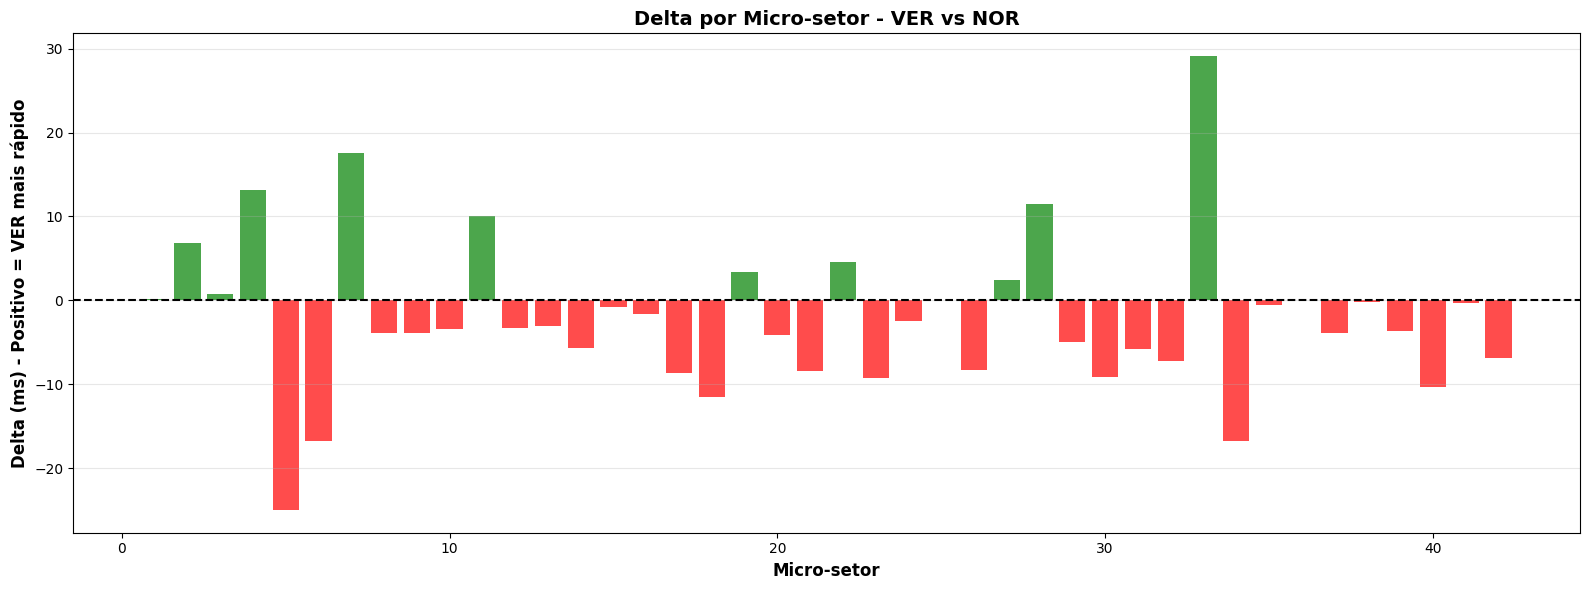


✅ Gráfico salvo: figures/07_microsector_delta.png


In [23]:

# 7. VISUALIZAÇÃO: DELTA AO LONGO DA PISTA


fig, ax = plt.subplots(figsize=(16, 6))

# Criar colormap baseado no delta (verde = driver_1 mais rápido, vermelho = mais lento)
colors = ['green' if d > 0 else 'red' for d in micro_df['Delta_ms']]

ax.bar(micro_df['Sector'], micro_df['Delta_ms'], color=colors, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Micro-setor', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Delta (ms) - Positivo = {driver_1} mais rápido', 
              fontsize=12, fontweight='bold')
ax.set_title(f'Delta por Micro-setor - {driver_1} vs {driver_2}', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/07_microsector_delta.png', dpi=300)
plt.show()

print("\n✅ Gráfico salvo: figures/07_microsector_delta.png")

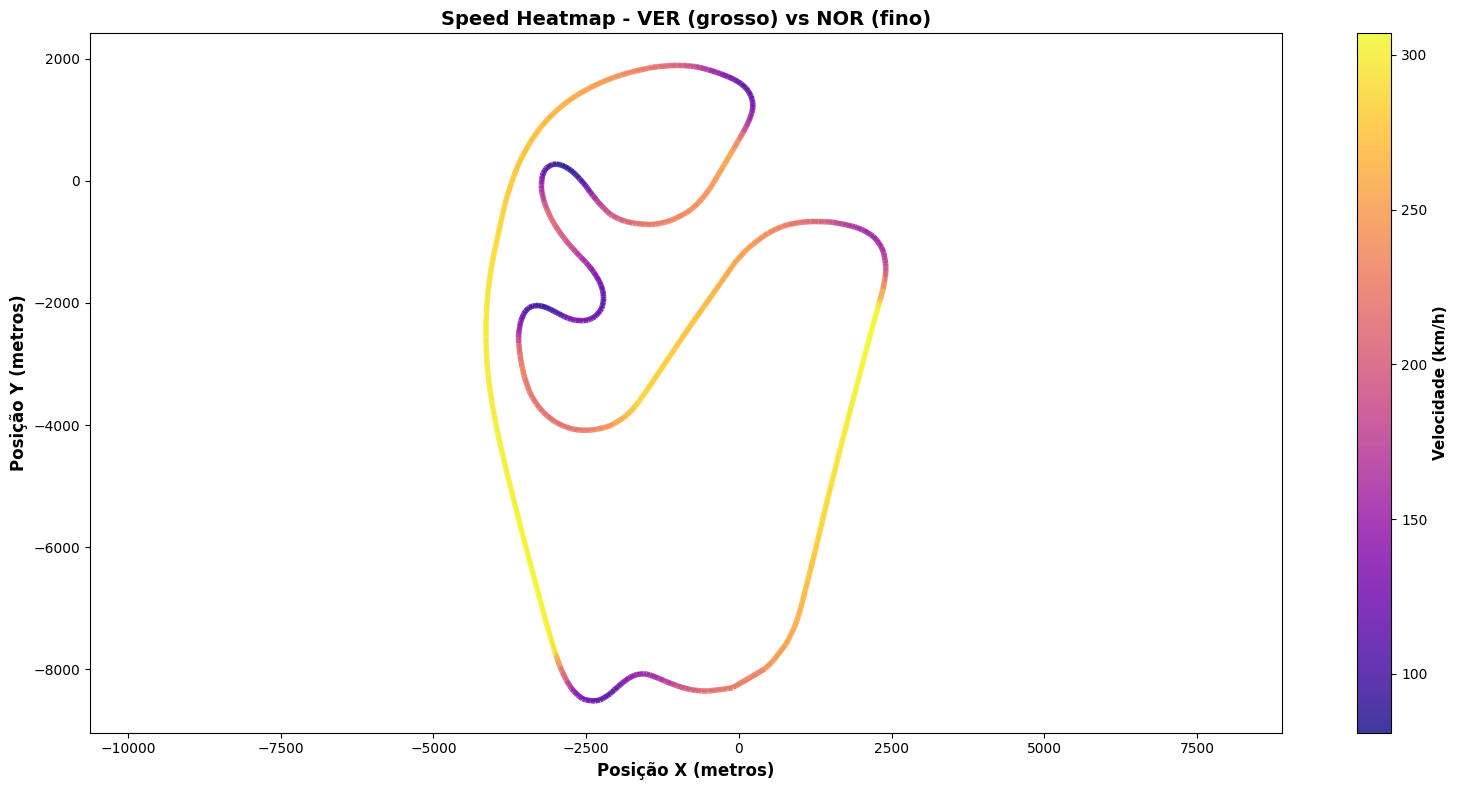

✅ Gráfico salvo: figures/08_speed_heatmap.png


In [24]:

# 8. VISUALIZAÇÃO: SPEED HEATMAP (AVANÇADO)


# Criar visualização colorida da pista baseado em velocidade

fig, ax = plt.subplots(figsize=(16, 8))

# Converter telemetria em segmentos de linha com cores
points_1 = np.array([tel_1['X'].values, tel_1['Y'].values]).T.reshape(-1, 1, 2)
segments_1 = np.concatenate([points_1[:-1], points_1[1:]], axis=1)

# Normalizar velocidade para colormap
norm = plt.Normalize(tel_1['Speed'].min(), tel_1['Speed'].max())
lc_1 = LineCollection(segments_1, cmap='plasma', norm=norm, linewidth=4, alpha=0.8)
lc_1.set_array(tel_1['Speed'])

line_1 = ax.add_collection(lc_1)

# Mesmo para driver 2 (offset ligeiramente para visualizar ambos)
points_2 = np.array([tel_2['X'].values + 5, tel_2['Y'].values + 5]).T.reshape(-1, 1, 2)
segments_2 = np.concatenate([points_2[:-1], points_2[1:]], axis=1)

lc_2 = LineCollection(segments_2, cmap='plasma', norm=norm, linewidth=2, alpha=0.5)
lc_2.set_array(tel_2['Speed'])

line_2 = ax.add_collection(lc_2)

# Colorbar
cbar = plt.colorbar(line_1, ax=ax)
cbar.set_label('Velocidade (km/h)', fontsize=11, fontweight='bold')

ax.set_xlabel('Posição X (metros)', fontsize=12, fontweight='bold')
ax.set_ylabel('Posição Y (metros)', fontsize=12, fontweight='bold')
ax.set_title(f'Speed Heatmap - {driver_1} (grosso) vs {driver_2} (fino)', 
             fontsize=14, fontweight='bold')
ax.axis('equal')

plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/08_speed_heatmap.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/08_speed_heatmap.png")

In [25]:

# 9. EXPORTAR ANÁLISE DE MICRO-SETORES


micro_df.to_csv('/workspaces/f1-race-analysis/data/processed/microsector_analysis.csv', index=False)
print("\n✅ Análise de micro-setores salva: data/processed/microsector_analysis.csv")


✅ Análise de micro-setores salva: data/processed/microsector_analysis.csv


In [26]:

# 10. RESUMO FINAL


print("\n" + "="*60)
print("🏁 RESUMO DA ANÁLISE DE TELEMETRIA")
print("="*60)
print(f"\nCorrida: GP São Paulo 2023")
print(f"Comparação: {driver_1} vs {driver_2}")
print(f"\nVolta mais rápida:")
print(f"  {driver_1}: {fastest_1['LapTime']}")
print(f"  {driver_2}: {fastest_2['LapTime']}")
print(f"  Delta total: {abs(delta):.3f}s")
print(f"\nDelta acumulado ao longo da pista:")
print(f"  Maior ganho de {driver_1}: +{micro_df['Delta_ms'].max():.1f}ms (setor {micro_df.loc[micro_df['Delta_ms'].idxmax(), 'Sector']:.0f})")
print(f"  Maior perda de {driver_1}: {micro_df['Delta_ms'].min():.1f}ms (setor {micro_df.loc[micro_df['Delta_ms'].idxmin(), 'Sector']:.0f})")
print(f"\nVelocidade média:")
print(f"  {driver_1}: {tel_1['Speed'].mean():.1f} km/h")
print(f"  {driver_2}: {tel_2['Speed'].mean():.1f} km/h")

print("\n✅ Análise Parte 2 completa!")



🏁 RESUMO DA ANÁLISE DE TELEMETRIA

Corrida: GP São Paulo 2023
Comparação: VER vs NOR

Volta mais rápida:
  VER: 0 days 00:01:13.422000
  NOR: 0 days 00:01:12.486000
  Delta total: 0.936s

Delta acumulado ao longo da pista:
  Maior ganho de VER: +29.1ms (setor 33)
  Maior perda de VER: -25.0ms (setor 5)

Velocidade média:
  VER: 209.5 km/h
  NOR: 209.9 km/h

✅ Análise Parte 2 completa!
